This is the code of sequential Bayesian history matching (SBHM) algorithm for the three degree-of-freedom mass-spring system. The SBHM algorithm aims to generate posterior samples of model parameters as data arrives sequentially. 

In [263]:
# basic packages
import time
import numpy as np
import pandas as pd 
import functools as ft
import math as math
from scipy.stats import multivariate_normal, norm, qmc, chi2

# graphs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.pyplot import figure
import seaborn as sns

# Gaussian process
from sklearn.model_selection import train_test_split
from scipy.spatial import distance_matrix
from scipy.linalg import cho_factor, cho_solve


In [264]:
# true model

true = np.array([0.16,0.32,0.45])
me = 0.001
md = 0.001
# reproduction, initial observation:
obs = np.array([0.15984389, 0.31984049, 0.45238688]) 
# new obs in case 1: np.array([0.1579, 0.3178, 0.4500]) 
# new obs in case 2: np.array([0.1548, 0.3190, 0.4443]) 
# generate a random obs: true + np.random.randn(3)*me+np.random.randn(3)*md
print(obs)

# K matrix
def conK(x): # x:2-d since k1 and k6 are assumed to be unknown
    k = np.ones(6)
    k[0] = x[0]
    k[5] = x[1]
    K = [[k[0]+k[3]+k[5],-k[3],-k[5]],
        [-k[3], k[1]+k[3]+k[4],-k[4]],
        [-k[5],-k[4],k[2]+k[4]+k[5]]]
    return np.array(K)

# M(mass) matrix
M = np.diag(np.repeat(1,3))

# mass-spring model
def threeDOF(K):
    R = np.linalg.inv(M).dot(K)
    eigenval, eigenvec = np.linalg.eig(R)
    freq = np.round(sorted(np.sqrt(eigenval)/(2*math.pi)),4)
    return(freq)


[0.15984389 0.31984049 0.45238688]


###Predictive Distributions from Gaussian Process Emulator (GPE)

A Gaussian process emulator approximates the simulator $\eta(\cdot)$ by combining a regression term with a zero-mean Gaussian process,

$$
\hat{\eta}(\mathbf{x})
=
\mathbf{h}(\mathbf{x})^\top\boldsymbol{\beta}
+
Z(\mathbf{x}).
$$

Here, $\mathbf{h}(\mathbf{x})$ contains $q$ known basis functions, and $Z(\mathbf{x})$ has covariance $\sigma^2 c(\mathbf{x},\mathbf{x}';\boldsymbol{\psi})$. The choice of $\mathbf{h}(\mathbf{x})$ is flexible. In this example, a linear regression term is used,

$$
\mathbf{h}(\mathbf{x})
=
(1,x_1,\ldots,x_d)^\top,
\qquad q=d+1.
$$

For $n$ training points, conditional on the correlation hyperparameters $\boldsymbol{\psi}$ and under the prior $p(\boldsymbol{\beta},\sigma^2)\propto1/\sigma^2$, the regression coefficients and process variance are estimated by

$$
\hat{\boldsymbol{\beta}}
=
(\mathbf{H}^{\top}\mathbf{C}^{-1}\mathbf{H})^{-1}
\mathbf{H}^{\top}\mathbf{C}^{-1}\mathbf{y},
$$

and

$$
\hat{\sigma}^2
=
\frac{
(\mathbf{y}-\mathbf{H}\hat{\boldsymbol{\beta}})^\top
\mathbf{C}^{-1}
(\mathbf{y}-\mathbf{H}\hat{\boldsymbol{\beta}})
}{
n-q-2
}.
$$

Here, $\mathbf{C}$ is the correlation matrix. The correlation hyperparameters are selected by maximising the marginal likelihood.

After integrating out uncertainty in $\boldsymbol{\beta}$ and $\sigma^2$, the predictive distribution at a new input $\mathbf{x}^*$ can be written as

$$
\hat{\eta}(\mathbf{x}^*)
=
m(\mathbf{x}^*)
+
s(\mathbf{x}^*)
\sqrt{\frac{\nu-2}{\nu}}
\,t_\nu,
\qquad
\nu=n-q,
$$

where $m(\mathbf{x}^*)$ and $s^2(\mathbf{x}^*)$ are the predictive mean and predictive variance, respectively.

For the training sample sizes considered here, the standardised Student's $t$ term is approximated by a standard Normal random variable,

$$
\sqrt{\frac{\nu-2}{\nu}}\,t_\nu
\approx
Z,
\qquad
Z\sim N(0,1).
$$

The predictive distribution used in the subsequent calculations is therefore

$$
\hat{\eta}(\mathbf{x}^*)
\approx
N\left(
m(\mathbf{x}^*),
s^2(\mathbf{x}^*)
\right).
$$

Accordingly, the emulator returns $m(\mathbf{x}^*)$ and $s(\mathbf{x}^*)$ directly, without applying an additional Student's $t$ scaling factor.

In [265]:
### kernels
def rbf_kernel(X1, X2, lengthscale):
    sqdist = np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=2)
    return np.exp(-0.5 * sqdist / lengthscale**2)


def matern52_kernel(X1, X2, lengthscale):
    dists = np.sqrt(np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=2))
    sqrt5d = np.sqrt(5) * dists / lengthscale
    return (1 + sqrt5d + 5 * dists**2 / (3 * lengthscale**2)) * np.exp(-sqrt5d)


### Gaussian Process Emulator
class GPE:
    def __init__(self, kernel="RBF", lengthscale=1.0, jitter=1e-8):
        self.kernel_type = kernel
        self.lengthscale = lengthscale
        self.jitter = jitter

    def _kernel(self, X1, X2, lengthscale=None):
        ls = self.lengthscale if lengthscale is None else lengthscale

        if self.kernel_type == "RBF":
            return rbf_kernel(X1, X2, ls)
        elif self.kernel_type == "Matern":
            return matern52_kernel(X1, X2, ls)
        else:
            raise ValueError("Unknown kernel type")

    def _fit_given_lengthscale(self, X, y, lengthscale):
        n, d = X.shape
        H = np.hstack([np.ones((n,1)), X])
        q = H.shape[1]

        K = self._kernel(X, X, lengthscale)
        K = K + self.jitter*np.eye(n)

        L = cho_factor(K, lower=True)

        Kinv_H = cho_solve(L, H)
        Kinv_y = cho_solve(L, y)

        A = H.T @ Kinv_H
        beta_hat = np.linalg.solve(A, H.T @ Kinv_y)

        r = y - H @ beta_hat
        RSS = r.T @ cho_solve(L, r)

        # estimate used in the profile restricted likelihood
        sigma2_REML = RSS/(n-q)

        # estimate corresponding to the predictive variance
        sigma2_pred = RSS/(n-q-2)

        logdetK = 2*np.sum(np.log(np.diag(L[0])))
        sign, logdetA = np.linalg.slogdet(A)

        if sign <= 0:
            return None

        loglik = (
            -0.5*logdetK
            -0.5*logdetA
            -0.5*(n-q)*np.log(sigma2_REML)
        )

        return {
            "lengthscale": lengthscale,
            "H": H,
            "K": K,
            "L": L,
            "beta_hat": beta_hat,
            "sigma2_hat": sigma2_pred,
            "loglik": loglik
        }

    def fit(self, X, y, lengthscale_grid=np.logspace(-1,1,10)):
        self.X = X
        self.y = y
        self.n, self.d = X.shape

        best = None
        best_ll = -np.inf

        for ls in lengthscale_grid:
            try:
                result = self._fit_given_lengthscale(X, y, ls)
            except np.linalg.LinAlgError:
                continue

            if result is not None and result["loglik"] > best_ll:
                best_ll = result["loglik"]
                best = result

        if best is None:
            raise RuntimeError("GPE fitting failed for all lengthscales")

        self.lengthscale = best["lengthscale"]
        self.H = best["H"]
        self.K = best["K"]
        self.L = best["L"]
        self.beta_hat = best["beta_hat"]
        self.sigma2_hat = best["sigma2_hat"]
        self.loglik = best_ll

        ### cache fixed quantities used repeatedly in prediction
        self.Kinv_r = cho_solve(
            self.L,
            self.y - self.H @ self.beta_hat
        )

        self.Kinv_H = cho_solve(
            self.L,
            self.H
        )

        self.A_inv = np.linalg.inv(
            self.H.T @ self.Kinv_H
        )

        return self

    def predict(self, X_new):
        n_new = X_new.shape[0]
        H_new = np.hstack([np.ones((n_new,1)), X_new])

        K_s = self._kernel(self.X, X_new)

        mu = H_new @ self.beta_hat + K_s.T @ self.Kinv_r

        Kinv_Ks = cho_solve(self.L, K_s)

        temp = H_new - K_s.T @ self.Kinv_H

        var = (
            1
            - np.sum(K_s*Kinv_Ks, axis=0)
            + np.sum(
                temp.T*(self.A_inv @ temp.T),
                axis=0
            )
        )

        var = self.sigma2_hat*np.maximum(var,0)

        return(mu,var)


### selection of the training data set for updating GPE
def maximin_subset_selection(points, subset_size):
    # Calculate the pairwise distance matrix
    dist_matrix = distance_matrix(points, points)
    
    subset_indices = [0]
    
    # Select points that maximize the minimum distance in the subset
    for _ in range(1, subset_size):
        # Calculate minimum distances from the subset to each point not yet selected
        min_distances = np.min(dist_matrix[subset_indices], axis=0)
        
        # Find the point with the maximum of these minimum distances
        next_index = np.argmax(min_distances)
        
        # Add the selected point to the subset
        subset_indices.append(next_index)
    
    return(points[subset_indices])


### GPE training and prediction for this example (multiple outputs)
def GPE_training(X,Y):
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)

    X = (X-X_mean)/X_std

    X_train,X_test,Y_train,Y_test = train_test_split(
        X,Y,test_size=0.33,random_state=42)

    y_mean = Y_train.mean(axis=0)
    y_std = Y_train.std(axis=0)

    Y_train = (Y_train-y_mean)/y_std

    models = []

    for i in range(Y.shape[1]):
        model = GPE(kernel="RBF",jitter=1e-8)
        model.fit(X_train,Y_train[:,i])
        models.append(model)

    ### predictive uncertainty on validation points
    y_vars = []

    for model in models:
        pre,var = model.predict(X_test)
        y_vars.append(var)

    y_vars = np.asarray(y_vars).T*(y_std**2)

    sigma = np.sqrt(np.mean(y_vars))

    return(sigma,y_std,y_mean,X_mean,X_std,models)


def prediction(y_std,y_mean,models,x_new):
    y_pre = []
    y_vars = []

    for model in models:
        pre,var = model.predict(x_new)
        y_pre.append(pre[0])
        y_vars.append(var[0])

    y_pre = np.asarray(y_pre)*y_std+y_mean
    y_vars = np.asarray(y_vars)*(y_std**2)

    y_cov = np.diag(y_vars)

    return(y_pre,y_cov)

In [266]:
# bounds for k1 and k6; make sure k1 k6 positive 
l_bounds = [0.05,0.05]
u_bounds = [10,10] 

### Implausibility measure (multivariate)
def Imp(obs,m,var):
    N = len(obs)
    V = np.repeat(md**2+me**2,N)+np.diag(var)
    return(np.sum((np.subtract(obs,m)**2)/V))

### modified metropolis algorithm
def modmetro(y_std,y_mean,X_mean, X_std,models,
             sd,ns,d,obs,seed,Y): # for each seed
    z = np.zeros((d,ns+1))
    z[:,0] = seed
    imp =  np.zeros(ns+1)
    mean, var = prediction(y_std,y_mean,models, ((seed-X_mean)/X_std).reshape(1, d))
    imp[0] = Imp(obs,mean,var)
    q = np.zeros(d)
    a = np.zeros(d)

    for m in range(ns):
        ### step 1 sampling
        a = z[:,m]+ multivariate_normal.rvs(mean=np.repeat(0,d), cov=np.diag(sd**2))
        rep_ind = np.where((l_bounds<a)&(a<u_bounds))
        q[:] = z[:,m]
        q[rep_ind] = a[rep_ind]
        
        ###step 2 determine whether q belongs to F_L or not
        q_rev = (q - X_mean)/X_std 
        mean, var = prediction(y_std,y_mean,models, q_rev.reshape(1, d)) ###store it
        imp_inter = Imp(obs,mean,var)
        if imp_inter < Y:
            z[:,m+1]=q
            imp[m+1] = imp_inter
        else:
            z[:,m+1]=z[:,m]
            imp[m+1] = imp[m]
        
    return([z,imp])

### make sure k1 k6 non-negative
def prior(x):
    between=True
    for i in range(len(x)):
        if not (u_bounds[i]>x[i] and l_bounds[i]<x[i]): 
            between=False
            break
    return(between)

### adaptive metropolis algorithm
def admetro(y_std,y_mean, X_mean, X_std,models,
    sd,d,obs,x,Y):
    res = x
    mean, var = prediction(y_std,y_mean,models, ((x-X_mean)/X_std).reshape(1, d))
    y = Imp(obs,mean,var)
    
    acc = 0
    zpot = x + multivariate_normal.rvs(mean=np.repeat(0,d), cov=np.diag(sd**2))
    mean, var = prediction(y_std,y_mean,models, ((zpot-X_mean)/X_std).reshape(1, d))
    y_z = Imp(obs,mean,var)
    
    if prior(zpot) and y_z < Y:
        alpha = multivariate_normal.pdf(zpot, mean=np.repeat(2,d), cov=np.diag(
        np.repeat(1,d))) / multivariate_normal.pdf(x, mean=np.repeat(2,d), cov=np.diag(
        np.repeat(1,d)))
        
        #norm.pdf(y_z) / norm.pdf(y)
        
        if np.random.uniform(0,1) <= alpha:
            res = zpot
            y = y_z
            acc = 1
    return([res,y,acc])

In [267]:
# Subset Simulation under the SMC framework

def sus(X, y_std,y_mean,X_mean,X_std, models, obs): #imp_list[im]
    #inner loop of SuS-based HM, i.e., subset simulation
    YF = chi2.ppf(0.95,len(obs)) #critical threshold 
    p = 0.1 #level probability
    n = X.shape[0] #number of samples
    d = X.shape[1] #dimension of samples
    nc = int(n*p) #number of Markov chains
    ns = int((1-p)/p) #number of states in each chain
    q = np.zeros(n) #probs
    
    L = 0
    Lmax = 100 # define the possible maximum of number of levels
    
    Xs = np.zeros((n,d,Lmax)) #samples for different levels
    nF = np.zeros(Lmax) # number of failure samples
    
    ys = np.zeros((Lmax,n)) # responses
    ys_or = np.zeros((Lmax,n)) # real responses
    
    Ys = np.zeros(Lmax)# intermediate threshold
    zs = np.zeros((nc,d, ns+1)) # seeds
    
    # Intialisation
    Xs[:,:,L] = X
    
    # Evaluation on emulators
    for i in range(n):
        x_rev = (Xs[i,:,L]-X_mean)/X_std
        mean,var = prediction(y_std,y_mean,models, x_rev.reshape(1, d))
        ys[L, i] = Imp(obs=obs,m=mean,var=var)
    
    nF[L] = len(np.where(ys[L,:]<YF)[0]) #samples falls in failure domain
    print('nFL=', nF[L])
    
    while (nF[L]/n)<1 and L<=5:
        L=L+1 # next conditional level is needed
        y_now = ys[L-1,:] 
        ind = sorted(range(len(y_now)), key=lambda k: y_now[k])# original index of increasing responses
        ys[L-1,:] = ys[L-1,ind] #renumbered responses
        Xs[:,:, L-1] = Xs[ind,:,L-1]
        Ys[L-1] = (ys[L-1,nc-1]+ys[L-1,nc])/2 #L^th intermediate threshold
        zs[:,:,0] = Xs[range(0,nc),:, L-1] # seeds of Markov chain
        print('L = ', L)
        print('intermediate threshold:',Ys[L-1])

        # step size used in sampling
        sd = 2.38*np.std(zs[:,:,0],axis = 0) # + np.repeat(1e-4,d) 
        print('std:', sd)
        
        # SMC structure
        ### resample
        q[:nc] = 1/nc
        q[nc:] = 0
        probs = q[:].tolist()
        
        for j in range(nc, n):
            A = np.random.multinomial(1, probs)
            A = A.tolist()
            A = A.index(1)
            Xs[j,:,L-1] = Xs[A,:,L-1]

        ### adaptive metropolis
        current_X = Xs[:,:,L-1].copy()

        for s in range(1,6):
            result = []
            
            for i in range(n):
                result.append(admetro(
                    y_std,y_mean,X_mean,X_std,models,
                    sd,d,obs,current_X[i,:],Ys[L-1]))
            
            acc = 0
            
            for j,i in enumerate(result):
                current_X[j,:] = i[0]
                ys[L,j] = i[1]
                
                if i[-1] == 1:
                    acc = acc+1
                    
            print(acc)
            
            if acc/n<=0.3:
                sd = np.sqrt(np.exp(np.log(sd**2)-np.repeat(np.log(d)/s,d)))
            else:
                sd = np.sqrt(np.exp(np.log(sd**2)+np.repeat(np.log(d)/s,d)))
                
            print('std:', sd)
        
        Xs[:,:,L] = current_X
        
        nF[L] = len(np.where(ys[L,:]<YF)[0])
        print('nFL=', nF[L])
            
    return(Xs[:,:,L])


In [268]:
### outer loop of HM
def HM(obs,n,d):
    YF = chi2.ppf(0.95,len(obs)) # thershold for non-implausible domain
    p = 0.1 # level probability
    w = 0 # initial wave
    Wmax = 100 # maximum wave
    sigma = 500 # intial GP variances
    Xw = np.zeros((n,d,Wmax)) #samples for different waves
    nF_or = np.zeros(Wmax) # number of failure samples
    ys_or = np.zeros((Wmax,n)) # responses on the original simulator
    
    # evulate samples on the original simulator
    for i in range(n):
        Xw[i,:,w] = np.maximum(np.array(l_bounds),
                           multivariate_normal.rvs(mean=np.repeat(2,d),cov=np.diag(
        np.repeat(0.04,d))))
        
        ys_or[w,i] = Imp(obs,threeDOF(conK(Xw[i,:,w])),
                                  np.diag(np.repeat(0,len(obs))))
        
    nF_or[w] = len(np.where(ys_or[w,:]<YF)[0])
    
    print('w = ',w)
    print('samples falls in failure domain:',nF_or[w])
    
    X_points = []
    Y_points = []
    
    while sigma>=me and nF_or[w]/n<p: 
        
        # Train GP emulator 
        if w<1: 
            subset_size = 100
        else:
            subset_size = 25

        new_X_points = maximin_subset_selection(
            Xw[:,:,w],subset_size)
        
        X_points.extend(new_X_points)
        
        Y_points.extend(np.apply_along_axis(
            lambda x: threeDOF(conK(x)),
            1,np.array(new_X_points)))
        
        sigma,y_std,y_mean,X_mean,X_std,models = GPE_training(
            np.array(X_points),np.array(Y_points))
        
        print('sigma:',sigma)
        
        # increment wave w and update samples based on GP emulator
        w = w+1

        Xw[:,:,w] = sus(
            Xw[:,:,w-1],
            y_std,y_mean,X_mean,X_std,
            models,obs)

        # evulate samples on the original simulator
        for i in range(n):
            ys_or[w,i] = Imp(
                obs,
                threeDOF(conK(Xw[i,:,w])),
                np.diag(np.repeat(0,len(obs))))
            
        nF_or[w] = len(np.where(ys_or[w,:]<YF)[0])

        print('w = ',w)
        print('samples falls in failure domain:',nF_or[w])
                    
    return(Xw[:,:,:(w+1)])

In [269]:
# History Matching

N = 1000
obs = obs
start_time = time.time()
X=HM(obs,N,2) # samples generated from HM for a static observation
print("--- %s seconds ---" % (time.time() - start_time))
y = np.zeros(X.shape[0])
for i in range(X.shape[0]):
    y[i] = Imp(obs,threeDOF(conK(X[i,:,-1])),np.diag(np.repeat(0,3)))
print('min of y=',min(y))



w =  0
samples falls in failure domain: 0.0
sigma: 1.5042497119473335e-05
nFL= 0.0
L =  1
intermediate threshold: 701.0306151163352
std: [0.4430807  0.21402378]
565
std: [0.62661074 0.30267533]
489
std: [0.74516995 0.35994366]
489
std: [0.83642498 0.4040231 ]
454
std: [0.91212791 0.44059031]
474
std: [0.97759449 0.472213  ]
nFL= 4.0
L =  2
intermediate threshold: 119.23471559681516
std: [2.70498184 0.80411964]
85
std: [1.912711   0.56859845]
155
std: [1.60839182 0.4781324 ]
153
std: [1.43291421 0.42596754]
190
std: [1.31398813 0.39061396]
201
std: [1.22599427 0.36445571]
nFL= 49.0
L =  3
intermediate threshold: 10.810164476277155
std: [2.17214034 0.66058309]
27
std: [1.53593516 0.46710278]
39
std: [1.29156237 0.39278506]
69
std: [1.15065126 0.3499317 ]
61
std: [1.05515186 0.32088879]
68
std: [0.9844915  0.29939982]
nFL= 495.0
L =  4
intermediate threshold: 2.5067565551878146
std: [1.21284629 0.17577878]
12
std: [0.85761184 0.12429437]
23
std: [0.72116272 0.10451869]
35
std: [0.64248294

In [270]:
# HM results

estimation = np.mean(X[:,:,-1],axis = 0)
print(estimation) # mean of non-implausible samples; estimation of unknown parameters
print(np.std(X[:,:,-1],axis = 0)) # variance of non-implausible samples
print(threeDOF(conK(estimation))) # output with the estimated parameters
# df = pd.DataFrame(X[:,:,-1]) # store data
# df.to_csv('3DOF_HM_new_final.csv')

[1.10857134 3.00935591]
[0.54106008 0.07705616]
[0.162  0.319  0.4522]


In [284]:
# Initialisation of SBHM

### metropolis algorithm
def accept(x,
           y_std,y_mean,X_mean,X_std,models,
           d,sigma,temp,obs):
    res = x
    
    x_rev = (x-X_mean)/X_std
    mean,var = prediction(
        y_std,y_mean,models,x_rev.reshape(1,d))
    
    imp = Imp(obs,mean,var)
    inner = np.exp(-0.5*imp)
    acc = 0
    
    zpot = x+multivariate_normal.rvs(
        mean=np.repeat(0,d),cov=np.diag(sigma))
    
    if prior(zpot):
        z_rev = (zpot-X_mean)/X_std
        meanz,varz = prediction(
            y_std,y_mean,models,z_rev.reshape(1,d))
        
        imp_z = Imp(obs,meanz,varz)
        inner_z = np.exp(-0.5*imp_z)
        
        alpha = np.exp(-0.5*temp*(imp_z-imp))
        
        if np.random.uniform(0,1)<=alpha:
            res = zpot
            inner = inner_z
            acc = 1
            
    return([res,inner,acc])


### bisection method
def bise(inner,lower,upper,Nthre,thre):
    a = lower
    b = upper
    
    for i in range(100):
        mid = (a+b)/2
        weights = inner**(mid-lower)
        w_sum = sum(weights)

        if w_sum!=0:
            weights = weights/w_sum
            ESS = 1/sum(weights**2)
        else:
            ESS = 0

        if abs(ESS-Nthre)<=thre:
            break
            
        if ESS<Nthre:
            b = mid
        else:
            a = mid
            
    return(mid)


### SMC after HM(SuS) to generate posterior samples for a static observation
def smcsus(obs,X):
    d = X.shape[1] #dimension of the input space 
    n = X.shape[0]
    L = 0 # zero level
    Nthre = 0.75*n # ESS threshold
    thre = 1 # stopping rule for bisection
    Lmax = 100 # define the possible maximum of number of levels
    Xs = np.zeros((n,d,Lmax)) #samples for different levels
    phi = np.zeros(Lmax)
    
    # generate initial samples based on non-implausible samples from HM
    mean = np.mean(X,axis=0)
    std = np.std(X,axis=0)+np.repeat(1e-4,d)
    
    sampler = qmc.LatinHypercube(d=d)
    sample = sampler.random(n=n)
    
    xs = qmc.scale(sample,np.maximum(mean-3*std,l_bounds),
                   np.minimum(mean+3*std,u_bounds))

    Xs[:,:,0] = xs ### samples for zero level
    zs = np.zeros((n,d)) ### resampling
    inner = np.zeros(n)
    
    q = np.zeros((Lmax,n)) ### normalised weight
    sigma = 2.38*np.diag(np.cov(np.transpose(xs)))
    
    ### retrain a GP here based on the non-implausible domain
    subset_size = 100
    X_points = maximin_subset_selection(Xs[:,:,L],subset_size)
    Y_points = np.apply_along_axis(lambda x: 
                            threeDOF(conK(x)),1,X_points)

    si,y_std,y_mean,X_mean,X_std,models = GPE_training(
        X_points,Y_points)
    
    while phi[L]<1: # stopping criterion
        
        ### likelihood
        for i in range(n):
            x_rev = (Xs[i,:,L]-X_mean)/X_std
            mean,var = prediction(
                y_std,y_mean,models,x_rev.reshape(1,d))
            inner[i] = np.exp(-0.5*Imp(obs,mean,var))

        ### specify the next tempering hyperparameter phi[L+1]
        q[L+1,:] = inner**(1-phi[L])           
        
        if sum(q[L+1,:])!=0:
            q[L+1,:] = q[L+1,:]/sum(q[L+1,:])
            ESS = 1/sum(q[L+1,:]**2)
        else:
            ESS = 0
            
        ## iterative bisection method to solve ESS approx N_thresh = alpha*N
        if ESS>Nthre:
            phi[L+1] = 1 
        else:
            phi[L+1] = bise(
                inner,phi[L],1,Nthre,thre)

        ### weights for the selected tempering parameter
        q[L+1,:] = inner**(phi[L+1]-phi[L])

        if sum(q[L+1,:])!=0:
            q[L+1,:] = q[L+1,:]/sum(q[L+1,:])
            
        print('Threshold =',phi[L+1])
        
        ### increment L
        L += 1
        Xs[:,:,L] = Xs[:,:,L-1]
        
        ### reweight
        probs = q[L,:].tolist()
        
        ### resample
        zs[:,:] = Xs[:,:,L] 
        
        for j in range(1,n+1):
            thre = np.random.uniform(0,1)
            bb = q[L,j-1]/max(q[L,:])
            
            if thre>=bb:
                A = np.random.multinomial(1,probs)
                A = A.tolist()
                A = A.index(1)
                Xs[j-1,:,L] = zs[A,:]
        
        ### MCMC move
        for s in range(1,6):
            result = []
            
            for i in range(n):
                result.append(accept(
                    Xs[i,:,L],
                    y_std,y_mean,X_mean,X_std,models,
                    d,sigma,phi[L],obs))
            
            acc = 0
            
            for j,i in enumerate(result):
                Xs[j,:,L] = i[0]
                inner[j] = i[1]
                
                if i[-1]==1:
                    acc = acc+1
                    
            print(acc)
            
            if acc/n<=0.3:
                sigma = np.exp(
                    np.log(sigma)-np.repeat(np.log(d)/s,d))
            else:
                sigma = np.exp(
                    np.log(sigma)+np.repeat(np.log(d)/s,d))
                
            print(sigma)
            
        # retrain GP based on updated high-probability regions
        subset_size = 100
        X_points = maximin_subset_selection(
            Xs[:,:,L],subset_size)
        Y_points = np.apply_along_axis(
            lambda x: threeDOF(conK(x)),1,X_points)
        
        si,y_std,y_mean,X_mean,X_std,models = GPE_training(
            X_points,Y_points)
                
    return(Xs[:,:,:(L+1)])

In [285]:

start_time = time.time()
NewX = smcsus(obs,X[:,:,-1])
print("--- %s seconds ---" % (time.time() - start_time))


Threshold = 0.006195068359375
467
[2.85656216 0.08509379]
391
[4.03978895 0.12034079]
397
[5.08981513 0.1516199 ]
428
[6.05284437 0.18030746]
448
[6.95289237 0.20711889]
Threshold = 0.006559010595083237
189
[3.47644619 0.10355944]
300
[2.45821867 0.07322759]
346
[3.09716145 0.09226098]
308
[3.68316643 0.10971741]
286
[3.20638261 0.09551455]
Threshold = 0.012152573294827107
203
[1.60319131 0.04775728]
324
[2.26725489 0.06753899]
268
[1.7995214  0.05360573]
296
[1.51321109 0.04507687]
319
[1.73822309 0.05177972]
Threshold = 0.024030377436728905
220
[0.86911155 0.02588986]
292
[0.61455467 0.0183069 ]
379
[0.77429036 0.02306524]
333
[0.92079161 0.02742935]
301
[1.05771181 0.03150805]
Threshold = 0.04714293929918918
210
[0.5288559  0.01575403]
285
[0.3739576  0.01113978]
349
[0.47115705 0.01403524]
310
[0.56030331 0.01669081]
280
[0.48777236 0.01453019]
Threshold = 0.09087758954619904
205
[0.24388618 0.0072651 ]
292
[0.17245357 0.0051372 ]
380
[0.21727789 0.00647247]
306
[0.25838841 0.00769

[1.03729989 3.03253435]


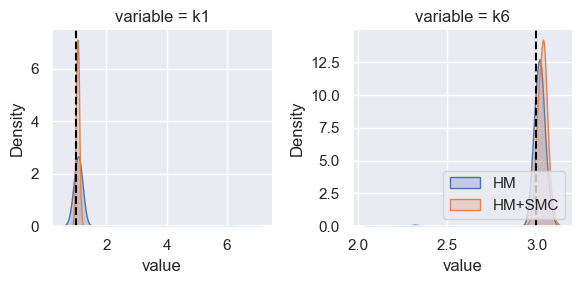

In [286]:
print(np.mean(NewX[:,:,-1], axis = 0)) # mean of posterior samples

# Comparison of non-implausible and posterior samples with true values
columns = ['k1','k6']
c1 = pd.DataFrame(X[:,:,-1], columns = columns)
c1.insert(0,'Algorithm','HM')
c2 = pd.DataFrame(NewX[:,:,-1], columns = columns)
c2.insert(0,'Algorithm','HM+SMC')
Data = pd.concat([c1,c2])
Data2 = pd.melt(Data, Data.columns[0], Data.columns[1:])

sns.set()
g = sns.FacetGrid(Data2, col="variable", hue="Algorithm",col_wrap=4,sharex=False,sharey=False)
g.map(sns.kdeplot, "value", fill=True)
true_values = [1,3]

for idx, ax in enumerate(g.axes.flat):
    true_val = true_values[idx]
    ax.axvline(true_val, color='black', linestyle='--', linewidth=1.5)

plt.legend(loc = 'lower right')
plt.show()

In [287]:
estimation = np.mean(NewX[:,:,-1],axis = 0) # mean of posterior samples; estimation of unknown parameters
print(estimation)
print(np.std(NewX[:,:,-1],axis = 0)) # variance of posterior samples
print(threeDOF(conK(estimation))) # output with the updated estiamted paramaters
# df = pd.DataFrame(NewX[:,:,-1]) # store data
# df.to_csv('3DOF_HMSMC_case2.csv')

[1.03729989 3.03253435]
[0.05381487 0.0276963 ]
[0.1601 0.3186 0.4525]


Now we directly update previously formed distribution when new data arrives

In [288]:
# Main procedure of SBHM

def accept_seq(x,
    y_std,y_mean,X_mean,X_std,models,
    d,sigma,obs_new,obs,temp):
    
    res = x
    
    x_rev = (x-X_mean)/X_std
    mean,var = prediction(
        y_std,y_mean,models,x_rev.reshape(1,d))
    
    imp_new = Imp(obs_new,mean,var)
    imp_old = Imp(obs,mean,var)
    
    inner = np.exp(-0.5*(imp_new-imp_old))
    acc = 0
    
    zpot = x + multivariate_normal.rvs(
        mean=np.repeat(0,d),cov=np.diag(sigma))
    
    if prior(zpot):
        zpot_rev = (zpot-X_mean)/X_std
        meanz,varz = prediction(
            y_std,y_mean,models,zpot_rev.reshape(1,d))
        
        impz_new = Imp(obs_new,meanz,varz)
        impz_old = Imp(obs,meanz,varz)
        
        inner_z = np.exp(-0.5*(impz_new-impz_old))
        
        alpha = np.exp(-0.5*(
            temp*(impz_new-imp_new)
            +(1-temp)*(impz_old-imp_old)
        ))
        
        if np.random.uniform(0,1)<=alpha:
            res = zpot
            inner = inner_z
            acc = 1
            
    return([res,inner,acc])


# the main sequential Monte Carlo sampler
def smc(obs,obs_new,X_smc):
    start_time = time.time()
    n = X_smc.shape[0]
    d = X_smc.shape[1]
    L = 0 # zero level
    Nthre = 0.6*n # ESS threshold
    thre = 1 # stopping rule for bisection
    Lmax = 100 # define the possible maximum of number of levels
    Xs = np.zeros((n,d,Lmax)) # samples for different iterations
    phi = np.zeros(Lmax)
    
    inner = np.zeros(n) ### update weights
    thre_inner = np.zeros(n) ### update weights for stopping rule
    
    Xs[:,:,0] = X_smc[:,:] ### samples for zero level
    zs = np.zeros((n,d)) ### resampling
    q = np.zeros((Lmax,n)) ### normalised weight
    sigma = 2.38*np.diag(np.cov(np.transpose(X_smc))) ### variance in metropolis
    boo = True
    
    ### initial GP training
    subset_size = 100
    X_points = maximin_subset_selection(Xs[:,:,L],subset_size)
    Y_points = np.apply_along_axis(
        lambda x: threeDOF(conK(x)),1,X_points)
    
    si,y_std,y_mean,X_mean,X_std,models = GPE_training(
        X_points,Y_points)

    ### ESS computation
    for i in range(n):
        x_rev = (Xs[i,:,L]-X_mean)/X_std
        mean,var = prediction(
            y_std,y_mean,models,x_rev.reshape(1,d))
        thre_inner[i] = Imp(obs_new,mean,var)
        
    if sum(thre_inner)!=0:
        thre_inner = thre_inner/sum(thre_inner)
        ESS = 1/sum(thre_inner**2)
    else:
        ESS = 0
        
    print('ESS = ',ESS)
    
    if ESS<=0.5*n:
        boo = False # ESS too low, no need to use previous information
        
    else:
        while phi[L]<1: # stopping criterion
            
            ### likelihood ratio
            for i in range(n):
                x_rev = (Xs[i,:,L]-X_mean)/X_std
                mean,var = prediction(
                    y_std,y_mean,models,x_rev.reshape(1,d))
                
                imp_new = Imp(obs_new,mean,var)
                imp_old = Imp(obs,mean,var)
                
                inner[i] = np.exp(-0.5*(imp_new-imp_old))
            
            ## ESS and temperature hyperparameter updates
            q[L+1,:] = inner**(1-phi[L])
            
            if sum(q[L+1,:])!=0:
                q[L+1,:] = q[L+1,:]/sum(q[L+1,:])
                ESS = 1/sum(q[L+1,:]**2)
            else:
                ESS = 0
            
            if ESS>Nthre:
                phi[L+1] = 1
                
            else:
                if L>0:
                    q[L+1,:] = inner**(phi[L]-phi[L-1])
                    q[L+1,:] = q[L+1,:]/np.sum(q[L+1,:])
                    ESS = 1/np.sum(q[L+1,:]**2)
                    
                    if ESS>0.5*n and ESS<0.9*n:
                        phi[L+1] = 2*phi[L]-phi[L-1]
                    else:
                        if ESS>=0.9*n:
                            phi[L+1] = bise(
                                inner,2*phi[L]-phi[L-1],
                                1,Nthre,thre)
                        else:
                            phi[L+1] = bise(
                                inner,phi[L],
                                2*phi[L]-phi[L-1],
                                Nthre,thre)
                else:
                    phi[L+1] = bise(
                        inner,phi[L],1,Nthre,thre)
            
            ### New weights corresponding to the selected temperature
            q[L+1,:] = inner**(phi[L+1]-phi[L])
            
            if sum(q[L+1,:])!=0:
                q[L+1,:] = q[L+1,:]/sum(q[L+1,:])
            
            print('Temperature =',phi[L+1])
            
            L += 1 ### increment
            Xs[:,:,L] = Xs[:,:,L-1]
            
            ### reweight
            probs = q[L,:].tolist()
            
            ### resample
            zs[:,:] = Xs[:,:,L]
            
            for j in range(1,n+1):
                thre = np.random.uniform(0,1)
                bb = q[L,j-1]/max(q[L,:])
                
                if thre>=bb:
                    A = np.random.multinomial(1,probs)
                    A = A.tolist()
                    A = A.index(1)
                    Xs[j-1,:,L] = zs[A,:]
            
            ### MCMC move
            for s in range(1,6):
                result = []
                
                for i in range(n):
                    result.append(accept_seq(
                        Xs[i,:,L],
                        y_std,y_mean,X_mean,X_std,models,
                        d,sigma,obs_new,obs,temp=phi[L]))
                
                acc = 0
                
                for j,i in enumerate(result):
                    Xs[j,:,L] = i[0]
                    inner[j] = i[1]
                    
                    if i[-1]==1:
                        acc += 1
                    
                print(acc)
                
                if acc/n<=0.3:
                    sigma = np.exp(
                        np.log(sigma)-np.repeat(np.log(d)/s,d))
                else:
                    sigma = np.exp(
                        np.log(sigma)+np.repeat(np.log(d)/s,d))
                
                print(sigma)
            
            ### retrain GP based on current particles
            subset_size = 100
            X_points = maximin_subset_selection(
                Xs[:,:,L],subset_size)
            Y_points = np.apply_along_axis(
                lambda x: threeDOF(conK(x)),1,X_points)
            
            si,y_std,y_mean,X_mean,X_std,models = GPE_training(
                X_points,Y_points)
            
    print("--- %s seconds ---" % (time.time()-start_time))
    
    return([Xs[:,:,:(L+1)],boo])

In [289]:
# true_new = np.array([0.95,3.0])
# print(true_new)
# true_inv = threeDOF(conK(true_new))
# print(true_inv)

obs_new =  np.array([0.1548, 0.3190, 0.4443]) # hard new obs
# simple new obs: np.array([0.1579, 0.3178, 0.4500]) 
# print(obs_new)

# obs = np.array([0.15984389, 0.31984049, 0.45238688])
# print(obs)

UpdateX, boo = smc(obs,obs_new,NewX[:,:,-1])

ESS =  928.9638721834617
Temperature = 0.0986328125
336
[0.01379895 0.00365498]
248
[0.00975733 0.00258446]
284
[0.0077444  0.00205129]
346
[0.0092097  0.00243941]
268
[0.00801751 0.00212363]
Temperature = 0.197265625
331
[0.01603501 0.00424725]
229
[0.01133847 0.00300326]
274
[0.00899935 0.00238369]
313
[0.01070209 0.0028347 ]
276
[0.00931671 0.00246775]
Temperature = 0.2958984375
276
[0.00465835 0.00123388]
415
[0.00658791 0.00174496]
363
[0.00830024 0.00219852]
308
[0.00987071 0.00261449]
272
[0.00859295 0.00227605]
Temperature = 0.39453125
332
[0.0171859  0.00455209]
196
[0.01215227 0.00321882]
239
[0.00964526 0.00255478]
294
[0.00811066 0.0021483 ]
330
[0.00931671 0.00246775]
Temperature = 0.4931640625
286
[0.00465835 0.00123388]
428
[0.00658791 0.00174496]
358
[0.00830024 0.00219852]
324
[0.00987071 0.00261449]
281
[0.00859295 0.00227605]
Temperature = 0.591796875
300
[0.00429647 0.00113802]
418
[0.00607613 0.00160941]
390
[0.00765545 0.00202773]
306
[0.00910391 0.00241139]
304
[

In [290]:
estimation = np.mean(UpdateX[:,:,-1],axis = 0) # mean of posterior samples for the second obs
print(estimation)
print(np.std(UpdateX[:,:,-1],axis = 0)) # variance
print(threeDOF(conK(estimation))) # output with updated parameters for the new obs
# df = pd.DataFrame(UpdateX[:,:,-1]) # store data
# df.to_csv('3DOF_SBHM_lowerA_case2.csv')

[0.85687344 2.93175286]
[0.05066477 0.02799551]
[0.1552 0.3174 0.4443]
